Import libraries and data to be used

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#define the raw data paths and read in the unnormalized yaw data for L1
l1_path=r"C:\Users\awatt\OneDrive\Documents\Spine-Stiffness-Python\NGIMU_L1 - 002F29E4\euler.csv"
l1_yaw_un_norm = pd.read_csv(l1_path, skiprows=1, header=None, usecols=[3]).values

#define the raw data paths and read in the unnormalized yaw data for S1
s1_path=r"C:\Users\awatt\OneDrive\Documents\Spine-Stiffness-Python\NGIMU_S1 - 002F2E12\euler.csv"
s1_yaw_un_norm = pd.read_csv(s1_path, skiprows=1, header=None, usecols=[3]).values

#define the raw data paths and read in the unnormalized yaw data for the winch
winch_path=r"C:\Users\awatt\OneDrive\Documents\Spine-Stiffness-Python\NGIMU_Winch - 002D4F6B\euler.csv"
winch_yaw_un_norm = pd.read_csv(winch_path, skiprows=1, header=None, usecols=[3]).values

#define the raw data paths and read in the unnormalized force data
force_path=r"C:\Users\awatt\OneDrive\Documents\Spine-Stiffness-Python\FullTestForce_020422_1.txt"
force_data_raw = pd.read_csv(force_path,sep=r'\s+', header=None)

#extract the untrimmed force and event marker data from the raw force data
force_untrimmed = force_data_raw[0].values
em_untrimmed = force_data_raw[1].values


# Plot the original data 
#plt.figure(figsize=(10, 5))
#plt.plot(l1_yaw_un_norm.flatten(), label='Original Data (Un-normalized)', color='gray', linestyle='--', alpha=0.7)
#plt.show()


Time normalise all Yaw data from IMUs to make them the same length using linear interpolation

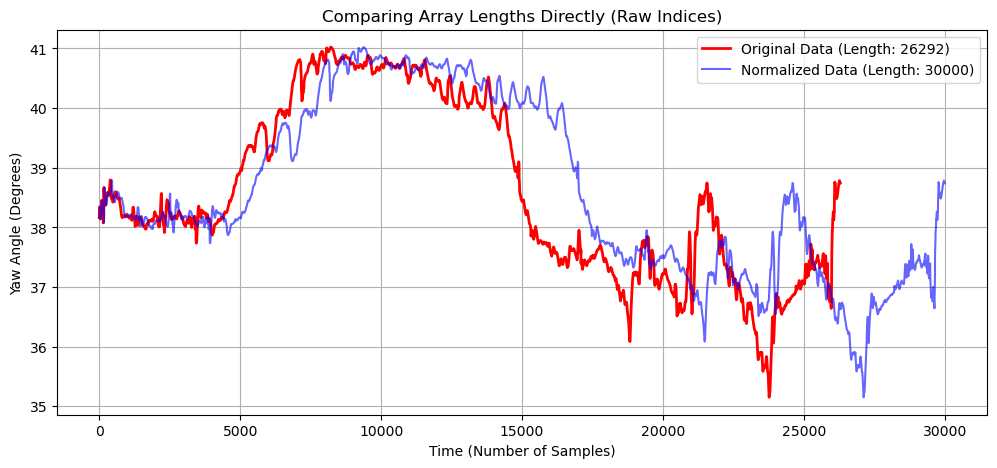

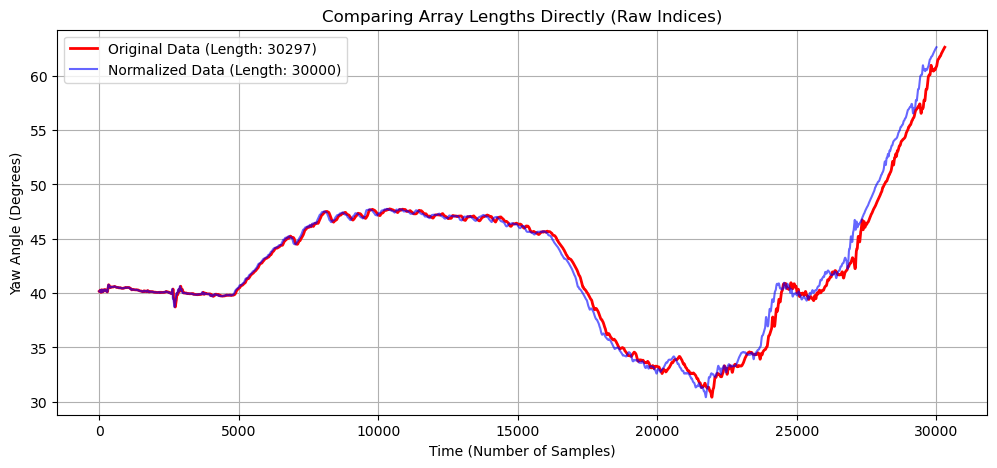

In [138]:
from scipy.interpolate import interp1d

def time_normalize_signal(x, target_length=30000):
    
    """Time-normalizes a signal to a specified target length using interpolation."""#
    x_flat=x.flatten()
    original_length=len(x_flat)
    old_time = np.arange(0, original_length)
    interpolator = interp1d(old_time, x_flat, kind='linear', bounds_error=True)
    new_time = np.linspace(0, original_length - 1, target_length)
    return interpolator(new_time)

l1_yaw_norm = time_normalize_signal(l1_yaw_un_norm)
s1_yaw_norm = time_normalize_signal(s1_yaw_un_norm)
winch_yaw_norm = time_normalize_signal(winch_yaw_un_norm)

# Plot the original and normalized data for L1 to compare lengths
plt.figure(figsize=(12, 5))
plt.plot(l1_yaw_un_norm.flatten(), label=f'Original Data (Length: {len(l1_yaw_un_norm)})', color='red', linewidth=2)
plt.plot(l1_yaw_norm, label=f'Normalized Data (Length: {len(l1_yaw_norm)})', color='blue', alpha=0.6)
plt.title('Comparing Array Lengths Directly (Raw Indices)')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('Yaw Angle (Degrees)')
plt.legend()
plt.grid(True)
plt.show()

# Plot the original and normalized data for S1 to compare lengths
plt.figure(figsize=(12, 5))
plt.plot(s1_yaw_un_norm.flatten(), label=f'Original Data (Length: {len(s1_yaw_un_norm)})', color='red', linewidth=2)
plt.plot(s1_yaw_norm, label=f'Normalized Data (Length: {len(s1_yaw_norm)})', color='blue', alpha=0.6)
plt.title('Comparing Array Lengths Directly (Raw Indices)')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('Yaw Angle (Degrees)')
plt.legend()
plt.grid(True)
plt.show()


Trim the force data to the length denoted by the start and end event markers

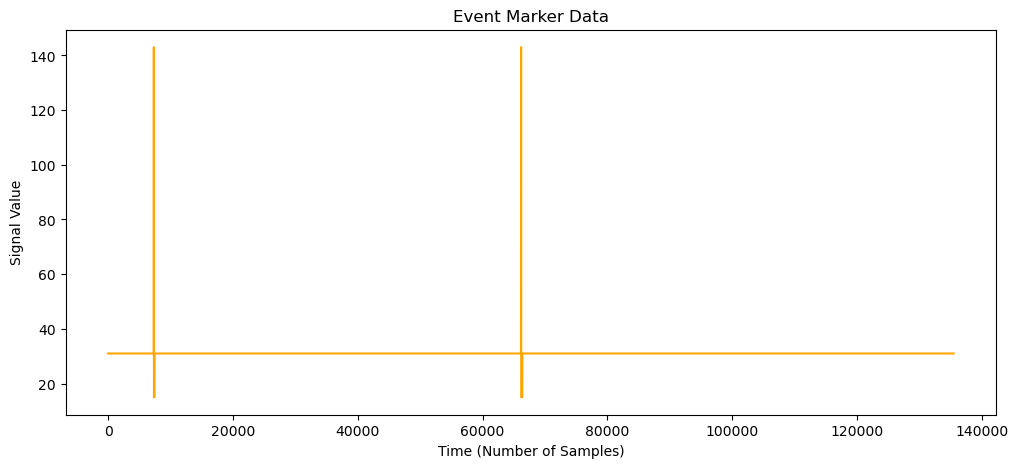

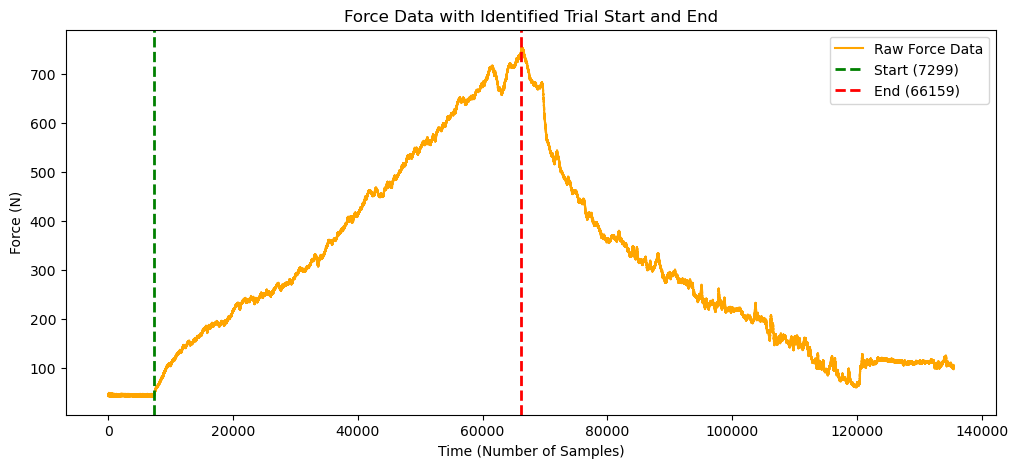

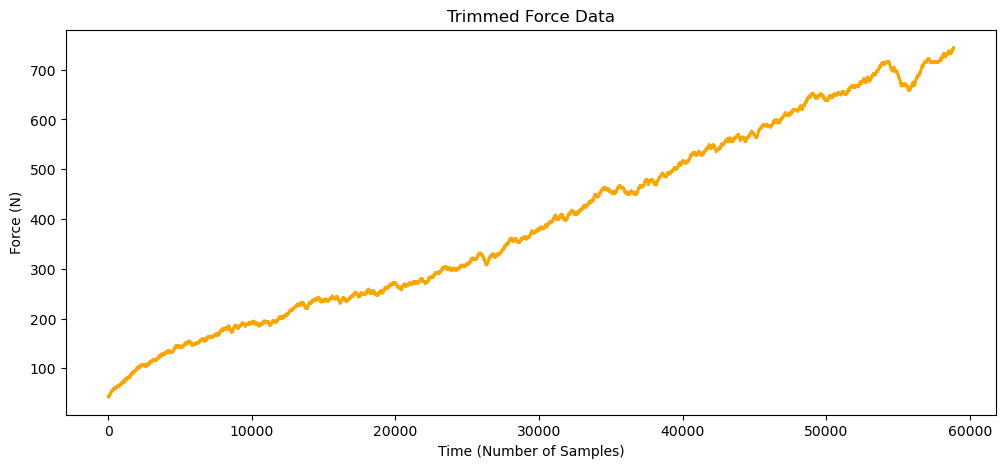

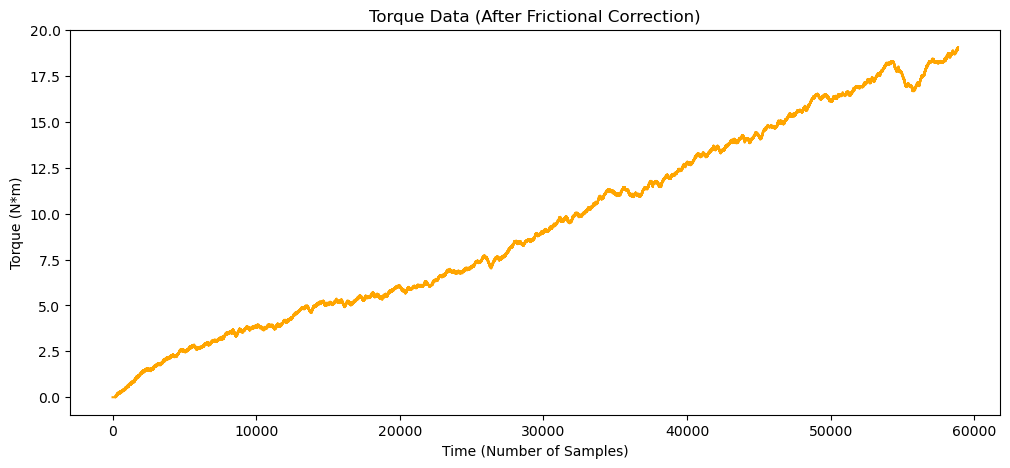

In [145]:
# Create a binary map (True/False or 1/0) of where the signal is above threshold
threshold = 100
above_threshold = (em_untrimmed > threshold).astype(int)

# Calculate the difference to find rising edges (where it goes from 0 to 1)
jumps = np.diff(above_threshold)
rising_edges = np.where(jumps == 1)[0]

# Extract start and end indices
start_index = rising_edges[0]
end_index = rising_edges[1]

# Trim the force data using the identified indices from the event marker data
force_trimmed = force_untrimmed[start_index:end_index]

#Convert the trimmed force data into N and then into torque based on diameter of the rotating
#platform and then subtracting the frictional torque in the system brought about by the person'
#weight acting on the rotating platform
ForceN=(force_trimmed/4000)*500
torque_orig=ForceN*0.22
p_weight=float(input("Enter the person's weight in kg: "))
frictional_torque=(0.007803597947275*p_weight)+0.753028773844885
torque_calib = torque_orig-frictional_torque
torque=np.maximum(torque_calib, 0.0)

plt.figure(figsize=(12, 5))
plt.plot(em_untrimmed, label='Event Markers (Untrimmed)', color='orange')
plt.title('Event Marker Data')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('Signal Value')
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(force_untrimmed, label='Raw Force Data', color='orange')
plt.axvline(x=start_index, color='green', linestyle='--', linewidth=2, label=f'Start ({start_index})')
plt.axvline(x=end_index, color='red', linestyle='--', linewidth=2, label=f'End ({end_index})')
plt.title('Force Data with Identified Trial Start and End')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('Force (N)')
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(force_trimmed, label='Force Data (Trimmed)', color='orange')
plt.title('Trimmed Force Data')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('Force (N)')
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(torque, label='Torque', color='orange')
plt.title('Torque Data (After Frictional Correction)')
plt.xlabel('Time (Number of Samples)')
plt.ylabel('Torque (N*m)')
plt.show()


Fit a 2nd order polynomial to smooth the torque data and then check for spikes that may be related to tensing

✅ Good Positive Fit (Poly2)
✅ Good Negative Fit (Poly2)


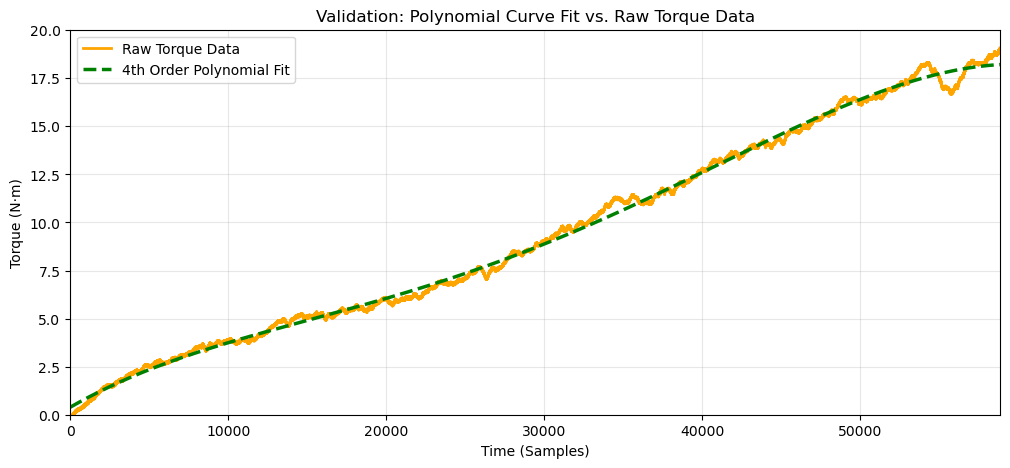

In [140]:
#Establishes the time index (1 to length of torque)
time = np.arange(1, len(torque) + 1)

#Fit a 2nd order polynomial and evaluate it
coefficients = np.polyfit(time, torque, 4)
torque_fit = np.polyval(coefficients, time)

#Calculates residuals (difference between real data and fitted line)
resid_torque = torque - torque_fit

#Checks against the threshold for tensing
threshold = 3.0
max_residual = np.max(resid_torque)
min_residual = np.min(resid_torque)

#Check positive residuals
if max_residual > threshold:
    print("⚠️ Warning: High Positive Residuals (Poly2)")
else:
    print("✅ Good Positive Fit (Poly2)")

#Checks negative residuals
if min_residual < -threshold:
    print("⚠️ Warning: High Negative Residuals (Poly2)")
else:
    print("✅ Good Negative Fit (Poly2)")

plt.figure(figsize=(12, 5))
plt.plot(time, torque, label='Raw Torque Data', color='orange', linewidth=2)
plt.plot(time, torque_fit, label='4th Order Polynomial Fit', color='green', linestyle='--', linewidth=2.5)
plt.title('Validation: Polynomial Curve Fit vs. Raw Torque Data')
plt.xlabel('Time (Samples)')
plt.ylabel('Torque (N·m)')
plt.xlim(0, len(torque))
plt.ylim(0, max(torque) * 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Use the winch IMU data to establish the start and end of the trial. This data is split into a loading and unloading phase. Then use these start and end indices to trim the L1 and S1 Yaw data. 

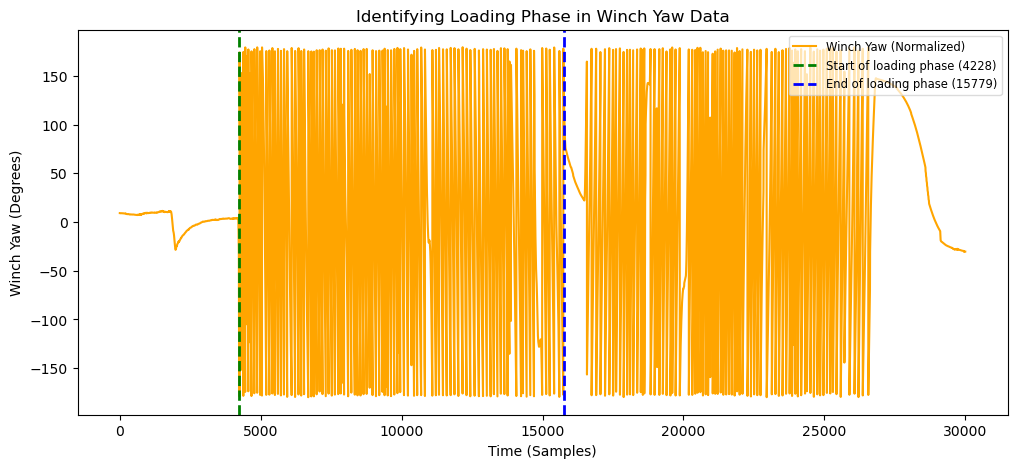

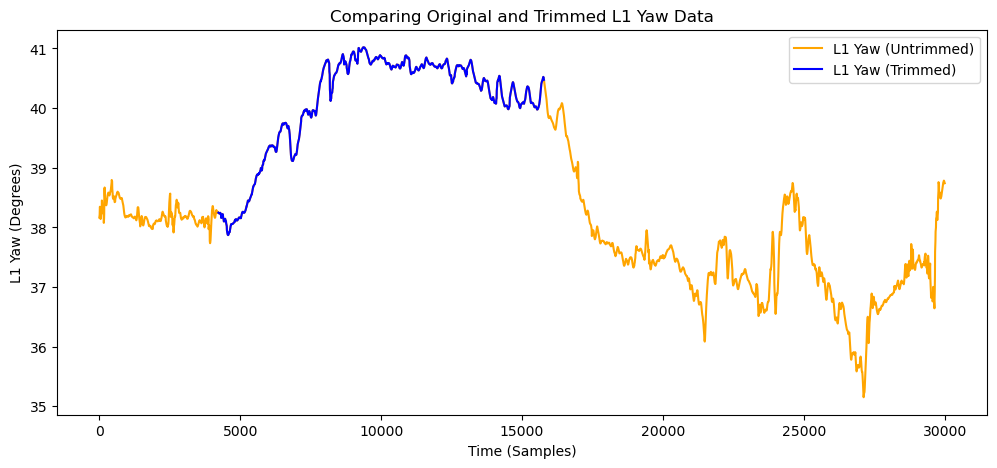

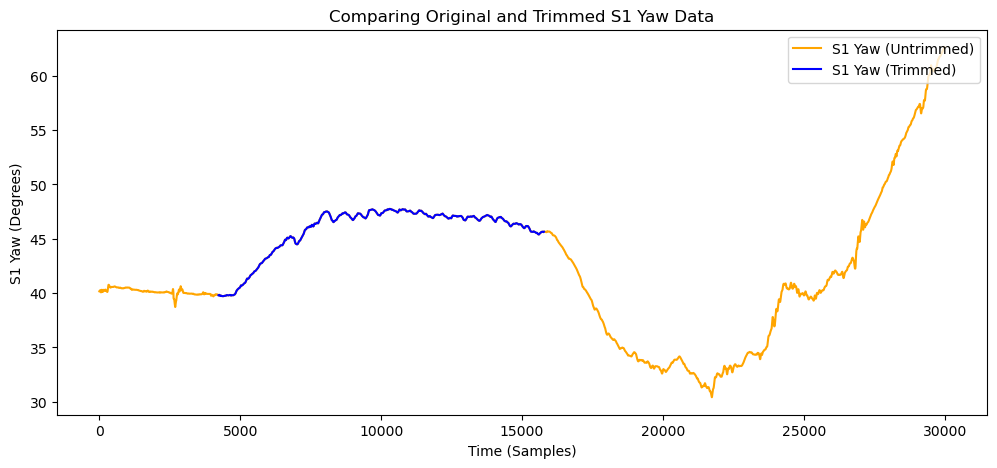

In [142]:
#plt.figure(figsize=(12, 5))
#plt.plot(winch_yaw_norm, label='Winch Yaw (Normalized)', color='orange')
#plt.show()



abs_signal = np.abs(winch_yaw_norm)
peak_threshold = 100
start_index_winch = np.where(abs_signal > peak_threshold)[0][0]


#plt.figure(figsize=(12, 5))
#plt.plot(abs_signal, label='Absolute Winch IMU Signal', color='blue')
#plt.show()

signal_diff = np.abs(np.diff(winch_yaw_norm))
#plt.figure(figsize=(12, 5))
#plt.plot(signal_diff, label='Difference in Winch Yaw (Normalized)', color='red')
#plt.show()

windowsize = 500
moving_activity = np.convolve(signal_diff, np.ones(windowsize)/windowsize, mode='same')
#plt.figure(figsize=(12, 5))
#plt.plot(moving_activity, label='Moving Average of Difference in Winch Yaw (Normalized)', color='green')
#plt.show()

post_start_activity = moving_activity[start_index:]
dip_threshold = 1.0
under_threshold_indices = np.where(post_start_activity < dip_threshold)[0]
valley_anchor_index = under_threshold_indices[0] + start_index
loading_phase_abs = abs_signal[:valley_anchor_index]
#plt.figure(figsize=(12, 5))
#plt.plot(loading_phase_abs, label='Loading Phase (Absolute Winch Yaw)', color='purple')
#plt.show()  
all_peak_indices = np.where(loading_phase_abs > peak_threshold)[0]
true_end_index_winch = all_peak_indices[-1]

plt.figure(figsize=(12, 5))
plt.plot(winch_yaw_norm, label='Winch Yaw (Normalized)', color='orange')
plt.axvline(x=start_index_winch, color='green', linestyle='--', linewidth=2, label=f'Start of loading phase ({start_index_winch})')
plt.axvline(x=true_end_index_winch, color='blue', linestyle='--', linewidth=2, label=f'End of loading phase ({true_end_index_winch})')
plt.title('Identifying Loading Phase in Winch Yaw Data')
plt.xlabel('Time (Samples)')
plt.ylabel('Winch Yaw (Degrees)')
plt.legend(loc='upper right',fontsize='small', framealpha=0.7)
plt.show()

l1_yaw_trim = l1_yaw_norm[start_index_winch:true_end_index_winch]
s1_yaw_trim = s1_yaw_norm[start_index_winch:true_end_index_winch]

original_timeline = np.arange(len(l1_yaw_norm))
trimmed_timeline = np.arange(start_index_winch, true_end_index_winch)
plt.figure(figsize=(12, 5))
plt.plot(original_timeline, l1_yaw_norm, label='L1 Yaw (Untrimmed)', color='orange')
plt.plot(trimmed_timeline, l1_yaw_trim, label='L1 Yaw (Trimmed)', color='blue' )
plt.title('Comparing Original and Trimmed L1 Yaw Data')
plt.xlabel('Time (Samples)')
plt.ylabel('L1 Yaw (Degrees)')
plt.legend(loc='upper right')
plt.show()  



plt.figure(figsize=(12, 5))
plt.plot(original_timeline, s1_yaw_norm, label='S1 Yaw (Untrimmed)', color='orange')
plt.plot(trimmed_timeline, s1_yaw_trim, label='S1 Yaw (Trimmed)', color='blue' )
plt.title('Comparing Original and Trimmed S1 Yaw Data')
plt.xlabel('Time (Samples)')
plt.ylabel('S1 Yaw (Degrees)')
plt.legend(loc='upper right')
plt.show()  
